/tmp/ipykernel_2235/902951519.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ativo, period=periodo)
[*********************100%***********************]  1 of 1 completed


Volatilidade: 0.2447
Sharpe Ratio: 2.1557
Max Drawdown: -0.0972


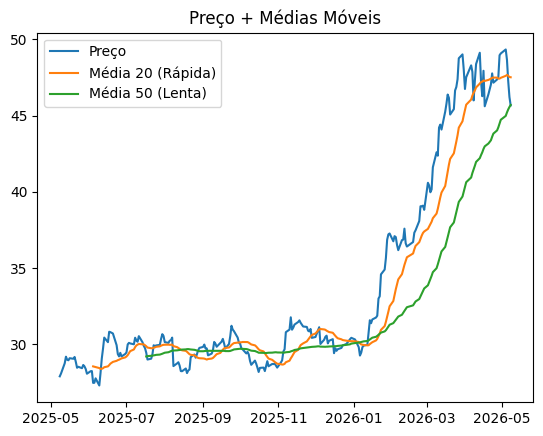

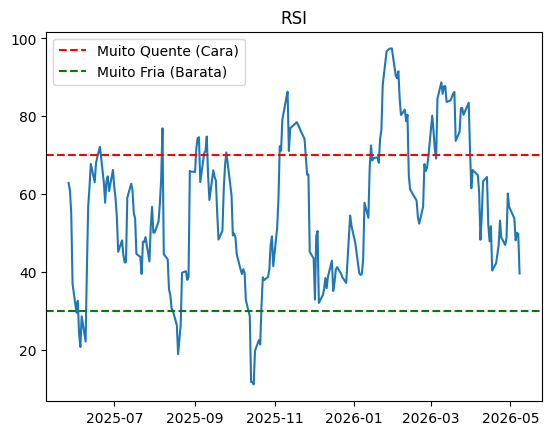

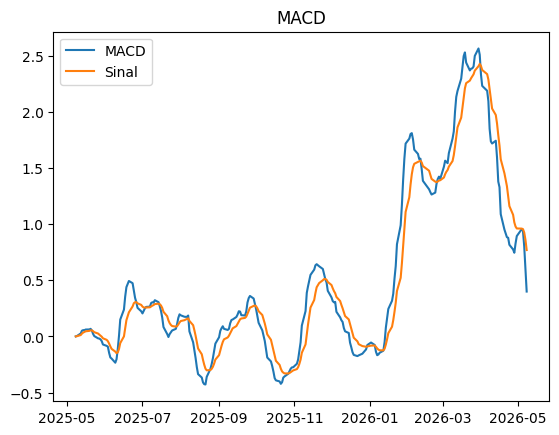

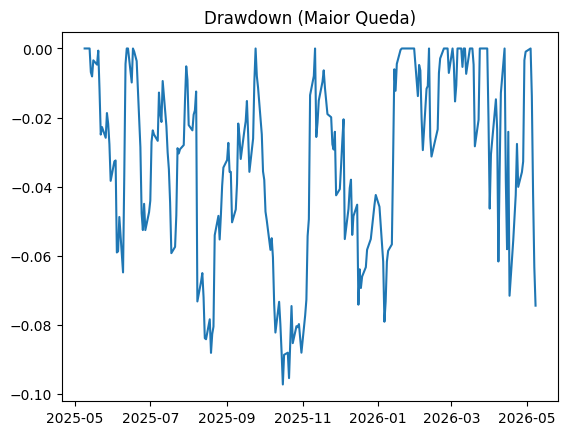

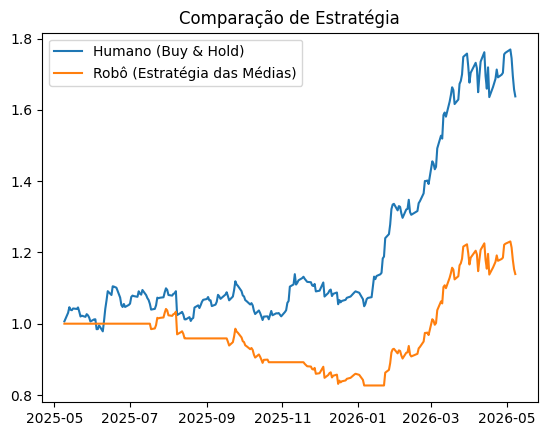

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# =========================
# INSTALAÇÃO DE BIBLIOTECAS
# =========================
# O 'pip install' baixa e instala as ferramentas externas necessárias:
# - yfinance: para conectar com o Yahoo Finance e baixar os dados da bolsa.
# - pandas: para organizar os dados em formato de tabela.
# - matplotlib: para desenhar e exibir os gráficos na tela.
# - openpyxl: para criar e salvar os dados no formato Excel.
# - numpy: para realizar cálculos matemáticos avançados (como raiz quadrada).
!pip install yfinance pandas matplotlib openpyxl numpy

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# CONFIGURAÇÃO
# =========================
# Define a ação a ser analisada (Petrobras) e o período de 1 ano ("1y")
ativo = "PETR4.SA"
periodo = "1y"

# =========================
# DADOS REAIS
# =========================
# Baixa os dados históricos de preços usando o Yahoo Finance
df = yf.download(ativo, period=periodo)

# Corrigir MultiIndex: Remove níveis extras nas colunas que o yfinance pode trazer
if isinstance(df.columns, pd.MultiIndex):
   df.columns = df.columns.get_level_values(0)

# Remove linhas com valores vazios (feriados ou erros de dados) para não atrapalhar os cálculos
df.dropna(inplace=True)

# =========================
# INDICADORES TÉCNICOS
# =========================

# --- Médias móveis ---
# Calcula o preço médio dos últimos 20 dias (linha rápida) e 50 dias (linha lenta)
df["MM20"] = df["Close"].rolling(20).mean()
df["MM50"] = df["Close"].rolling(50).mean()

# --- RSI (Índice de Força Relativa) ---
# É o 'termômetro' da ação. Acima de 70: ação muito quente/cara. Abaixo de 30: ação muito fria/barata.
delta = df["Close"].diff() # Diferença de preço de um dia para o outro
gain = (delta.where(delta > 0, 0)).rolling(14).mean() # Média dos dias de lucro
loss = (-delta.where(delta < 0, 0)).rolling(14).mean() # Média dos dias de prejuízo

rs = gain / loss # Calcula a força relativa
df["RSI"] = 100 - (100 / (1 + rs)) # Aplica a fórmula matemática do RSI

# --- MACD ---
# É o 'radar de tendências'. Mostra se a probabilidade está indo para alta ou para baixa.
ema12 = df["Close"].ewm(span=12).mean() # Média exponencial rápida
ema26 = df["Close"].ewm(span=26).mean() # Média exponencial lenta

df["MACD"] = ema12 - ema26 # A linha MACD é a diferença entre as duas
df["Signal"] = df["MACD"].ewm(span=9).mean() # Linha de sinal para confirmar o alerta da tendência

# =========================
# MÉTRICAS FINANCEIRAS
# =========================

# Calcula a variação percentual diária do preço da ação
df["Retorno"] = df["Close"].pct_change()

# --- Volatilidade anual ---
# Mede o risco geral (o sobe e desce louco do preço no ano)
volatilidade = df["Retorno"].std() * np.sqrt(252)

# --- Sharpe Ratio ---
# Mede o 'custo-benefício'.
sharpe = (df["Retorno"].mean() * 252) / volatilidade

# --- Drawdown ---
# Mede a pior queda que o investimento já deu desde o seu topo histórico
df["Acumulado"] = (1 + df["Retorno"]).cumprod() # Retorno acumulado
df["Max"] = df["Acumulado"].cummax() # Valor máximo alcançado (o topo da montanha)
df["Drawdown"] = df["Acumulado"] / df["Max"] - 1 # Calcula qual foi a queda do topo até o fundo

max_drawdown = df["Drawdown"].min() # Registra o pior momento

# Imprime os resultados na tela para o usuário ver
print("Volatilidade:", round(volatilidade, 4))
print("Sharpe Ratio:", round(sharpe, 4))
print("Max Drawdown:", round(max_drawdown, 4))

# =========================
# ESTRATÉGIA (CRUZAMENTO MM)
# =========================
# Um robô investidor baseado em regras.
df["Sinal"] = 0 # O robô começa sem fazer nada (0)

# Regra: Se a média rápida (20 dias) ultrapassar a média lenta (50 dias), é hora de comprar (Sinal 1)
df.loc[df["MM20"] > df["MM50"], "Sinal"] = 1

# Calcula o lucro ou prejuízo do nosso robô (usa shift para simular que só compramos no dia seguinte)
df["Estratégia"] = df["Sinal"].shift(1) * df["Retorno"]

# Acumula o resultado dessa estratégia no tempo
df["Retorno_Acumulado"] = (1 + df["Estratégia"]).cumprod()

# =========================
# GRÁFICOS
# =========================
# Usa a biblioteca matplotlib para criar imagens que facilitam ver tudo isso acontecendo

# 1. Gráfico de Preço e Médias
plt.figure()
plt.plot(df["Close"], label="Preço")
plt.plot(df["MM20"], label="Média 20 (Rápida)")
plt.plot(df["MM50"], label="Média 50 (Lenta)")
plt.title("Preço + Médias Móveis")
plt.legend()
plt.show()

# 2. Gráfico do Termômetro RSI
plt.figure()
plt.plot(df["RSI"])
plt.axhline(70, color='red', linestyle='--', label="Muito Quente (Cara)")
plt.axhline(30, color='green', linestyle='--', label="Muito Fria (Barata)")
plt.legend()
plt.title("RSI")
plt.show()

# 3. Gráfico do Radar MACD
plt.figure()
plt.plot(df["MACD"], label="MACD")
plt.plot(df["Signal"], label="Sinal")
plt.title("MACD")
plt.legend()
plt.show()

# 4. Gráfico Drawdown
plt.figure()
plt.plot(df["Drawdown"])
plt.title("Drawdown (Maior Queda)")
plt.show()

# 5. Robô (Estratégia) vs Humano (Ficar com a ação)
plt.figure()
plt.plot((1 + df["Retorno"]).cumprod(), label="Humano (Buy & Hold)")
plt.plot(df["Retorno_Acumulado"], label="Robô (Estratégia das Médias)")
plt.legend()
plt.title("Comparação de Estratégia")
plt.show()

# =========================
# EXPORTAR EXCEL
# =========================
# Salva toda a tabela com os cálculos em um arquivo Excel
df.to_excel("analise_avancada.xlsx")

# Comandos do Colab para baixar a planilha para o seu computador
from google.colab import files
files.download("analise_avancada.xlsx")